In [1]:
# =========================================
# 0) Imports + paths
# =========================================
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
# =========================================
# Reproducibility / seed
# =========================================
import random
import numpy as np
import torch
import os

SEED = 50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# For deterministic behavior (slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed set to {SEED}")

DATA_DIR      = './airbus_data/'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_v2")
TEST_IMG_DIR  = os.path.join(DATA_DIR, "test_v2")
train_csv     = os.path.join(DATA_DIR, 'train_ship_segmentations_v2.csv')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("TRAIN_IMG_DIR exists:", os.path.isdir(TRAIN_IMG_DIR))
print("TEST_IMG_DIR exists:", os.path.isdir(TEST_IMG_DIR))
print("train_csv exists:", os.path.isfile(train_csv))


Seed set to 50
DEVICE: cuda
TRAIN_IMG_DIR exists: True
TEST_IMG_DIR exists: True
train_csv exists: True


In [2]:
from sklearn.model_selection import train_test_split
train_df = pd.read_csv(train_csv)
# Labeling(1 if has ship else 0)
train_df['has_ship'] = train_df['EncodedPixels'].notnull().astype(int)

# Group all rows that belong to same image
image_grouped = train_df.groupby('ImageId')['has_ship'].max().reset_index()
image_grouped.rename(columns={'has_ship': 'has_ship_label'}, inplace=True)

# Balancing due to lot of empty pictures -> 1:2 ratio of has ships and no ships so it doesnt overfit.
positive = image_grouped[image_grouped['has_ship_label'] == 1]
negative = image_grouped[image_grouped['has_ship_label'] == 0].sample(len(positive) * 2, random_state=42)
balanced_df = pd.concat([positive, negative])
_, temp_df = train_test_split(
    balanced_df,
    test_size=0.1,
    random_state=42,
    stratify=balanced_df["has_ship_label"] # ensure that we keep the same ratio of ships/no-ships pictures
)
# split TEMP INTO VALIDATION(5%) AND TEST(5%) 
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['has_ship_label']
)

demo_ids = val_df['ImageId'].values


In [3]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class DoubleConv(nn.Module):
    """
    A helper block: (Convolution => BN => ReLU) * 2
    Every step in U-Net essentially does this twice.
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # First Conv Layer
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Second Conv Layer
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Encoder Part (Going Down) ---
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # --- Bottleneck (Floor) ---
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # --- Decoder Part (Going Up) ---
        for feature in reversed(features):
            # Upsampling: Doubles the spatial dimensions (H, W)
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # --- Final Output Layer ---
        # Reduces features to 1 channel (Ship vs Background)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # 1. Run Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x) # Save output for skip connection
            x = self.pool(x)

        # 2. Run Bottleneck
        x = self.bottleneck(x)

        # Reverse skip connections list (we need the last one first)
        skip_connections = skip_connections[::-1]

        # 3. Run Decoder
        for idx in range(0, len(self.ups), 2):
            # Upsample
            x = self.ups[idx](x)
            
            # Get the corresponding skip connection
            skip_connection = skip_connections[idx//2]

            # Resize if dimensions don't match perfectly (rare with 768x768 but good safety)
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            # Concatenate skip connection with current input
            concat_skip = torch.cat((skip_connection, x), dim=1)
            
            # Run Double Convolution
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)


In [4]:
# =========================================
# 3) Load your best model checkpoint
#    Set BEST_MODEL_PATH to your saved best weights.
# =========================================
BEST_MODEL_PATH = "custom_unet_best.pth"   # <-- change to your file (e.g. "dummy_unet.pth")

model = UNet(in_channels=3, out_channels=1).to(DEVICE)

state = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

# if you saved a full model object with torch.save(model, path)
if isinstance(state, nn.Module):
    model = state.to(DEVICE)
    print("Loaded FULL model object from:", BEST_MODEL_PATH)
else:
    # if DataParallel was used when saving, keys start with "module."
    if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)
    print("Loaded state_dict from:", BEST_MODEL_PATH)

model.eval()


Loaded state_dict from: custom_unet_best.pth


C:\Users\PC\AppData\Local\Temp\ipykernel_20900\1456152127.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(BEST_MODEL_PATH, map_location=DEVICE)


UNet(
  (ups): ModuleList(
    (0): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), p

In [5]:
# =========================================
# 4) Utilities: image loading + preprocessing for test images
#    Resize to 384x384 by default (change if your training used another size).
# =========================================
def load_test_image(path, size=(384, 384)):
    img = Image.open(path)

    # force RGB (3 channels)
    img = img.convert("RGB")

    if size is not None:
        img = img.resize(size, resample=Image.BILINEAR)

    # PIL -> numpy float32 [H,W,3] in [0,1]
    arr = np.asarray(img).astype(np.float32) / 255.0

    # [H,W,3] -> [3,H,W]
    arr = np.transpose(arr, (2, 0, 1))

    # to torch [1,3,H,W]
    x = torch.from_numpy(arr).unsqueeze(0)
    return x, img  # return tensor and PIL for visualization


In [6]:
# =========================================
# Decode RLE + build REAL ground-truth masks (Airbus)
# =========================================
from PIL import Image
def rle_decode(mask_rle, shape=(768, 768)):
    # Return full black mask if RLE is missing
    if pd.isnull(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    
    s = mask_rle.split()
    # RLE odd nums -> length even nums-> start values
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T  # Transpose to align with right direction



def build_gt_mask(image_id, df, shape=(768, 768)):
    """
    Combines all ship masks for this image (OR).
    If no ships -> returns zeros.
    """
    rows = df[df["ImageId"] == image_id]["EncodedPixels"].values
    if len(rows) == 0:
        return np.zeros(shape, dtype=np.uint8)

    m = np.zeros(shape, dtype=np.uint8)
    for rle in rows:
        m |= rle_decode(rle, shape=shape)
    return m

def resize_mask_nearest(mask_hw, size=(384, 384)):
    """
    mask_hw: np.uint8 [H,W] in {0,1}
    size: (W,H) for PIL resize, but we'll pass (384,384) consistently.
    """
    pil = Image.fromarray((mask_hw * 255).astype(np.uint8))
    pil = pil.resize(size, resample=Image.NEAREST)
    out = (np.asarray(pil) > 127).astype(np.uint8)
    return out


In [7]:
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from PIL import Image
import os

# ----------------------------
# 2) Your dataset (as-is, but uses the rle_decode above)
# ----------------------------
from torch.utils.data import Dataset
masks = train_df

class AirbusDataset(Dataset):
    def __init__(self, image_ids, img_dir, mask_df, transforms=None):
        self.image_ids = list(image_ids)
        self.img_dir = img_dir
        self.transforms = transforms
        self.mask_groups = mask_df.groupby('ImageId')

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # 1) Load image
        try:
            image = np.array(Image.open(img_path).convert("RGB"))
        except Exception as e:
            print(f"Warning: Error loading {img_name}: {e}. Using empty image.")
            image = np.zeros((768, 768, 3), dtype=np.uint8)

        # 2) Find masks for this image
        try:
            img_masks = self.mask_groups.get_group(img_name)
        except KeyError:
            img_masks = None

        # 3) Decode RLE -> mask
        mask = np.zeros((768, 768), dtype=np.float32)
        if img_masks is not None:
            for rle in img_masks["EncodedPixels"].values:
                if isinstance(rle, str):
                    mask += rle_decode(rle, shape=(768, 768))

        mask = np.clip(mask, 0, 1)

        # 4) Augmentations
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]   # torch tensor [3,H,W]
            mask = augmented["mask"]     # torch tensor or numpy depending on pipeline

        return image, mask

# ----------------------------
# 4) Create dataset + loader for demo
#    IMPORTANT: for demo visuals, disable random flips/brightness if you want stable pictures
# ----------------------------
# If you want EXACT reproducible visuals, use a non-augmenting transform here (no flip/brightness).
# Keep Normalize + Resize + ToTensorV2 (same as training).
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception as e:
    raise RuntimeError("You said you use Albumentations. Make sure albumentations and ToTensorV2 are imported.")

IMG_SIZE = 384

demo_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

demo_dataset = AirbusDataset(demo_ids, TRAIN_IMG_DIR, masks, transforms=demo_transform)

demo_loader = DataLoader(
    demo_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ----------------------------
# 5) Dice score function (your idea, but correct per-image averaging)
# ----------------------------
from tqdm import tqdm

def check_accuracy(loader, model, device="cuda"):
    model.eval()
    dice_score = 0
    
    print("Running validation...")
    with torch.no_grad(): # No need to calculate gradients -> faster
        for x, y in tqdm(loader):
            x = x.to(device).float()
            y = y.unsqueeze(1).to(device)
            y = (y > 0).float()
            # Model output
            preds = torch.sigmoid(model(x))
            
            # Binomization (0 or 1)
            preds = (preds > 0.5).float()
            preds = preds.cpu()
            y = y.cpu()
            # Calculate dice 
            intersection = (preds * y).sum()
            dice_score += (2. * intersection) / (preds.sum() + y.sum() + 1e-8)

    final_score = dice_score/len(loader)
    print(f"Validation Dice Score: {final_score:.4f}")
    model.train()
    return final_score

# Running dice validation
demo_dice = check_accuracy(demo_loader, model)


Running validation...


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:39<00:00,  1.25it/s]

Validation Dice Score: 0.8825


In [8]:
# =========================================
# Controlled sampling: 8 ship + 2 no-ship (10 total) WITH real GT masks
# =========================================
TOTAL_SAMPLES = 10
N_SHIP = 8
N_NO_SHIP = 2

ship_images = train_df[train_df["EncodedPixels"].notna()]["ImageId"].unique()
all_images = train_df["ImageId"].unique()
no_ship_images = list(set(all_images) - set(ship_images))

sample_ship = random.sample(list(ship_images), min(N_SHIP, len(ship_images)))
sample_no_ship = random.sample(list(no_ship_images), min(N_NO_SHIP, len(no_ship_images)))

sample_files = sample_ship + sample_no_ship
random.shuffle(sample_files)

print("sample_files:", sample_files)


sample_files: ['e0214dd48.jpg', '5f70594d6.jpg', '821be7828.jpg', 'bac64d716.jpg', 'c4ab39e1e.jpg', '8fabe561f.jpg', '21c89d41e.jpg', '68cccb0a9.jpg', '7ea8d8d96.jpg', 'fb513b540.jpg']


./airbus_data/train_v2\e0214dd48.jpg


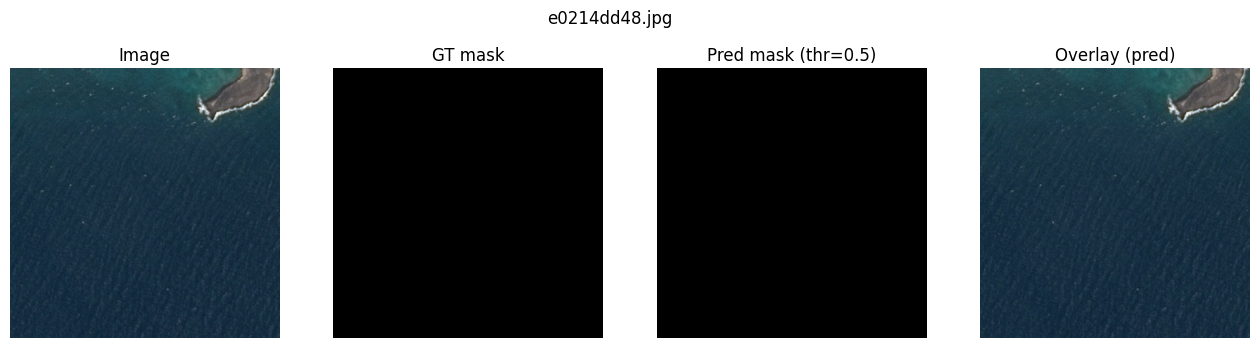

./airbus_data/train_v2\5f70594d6.jpg


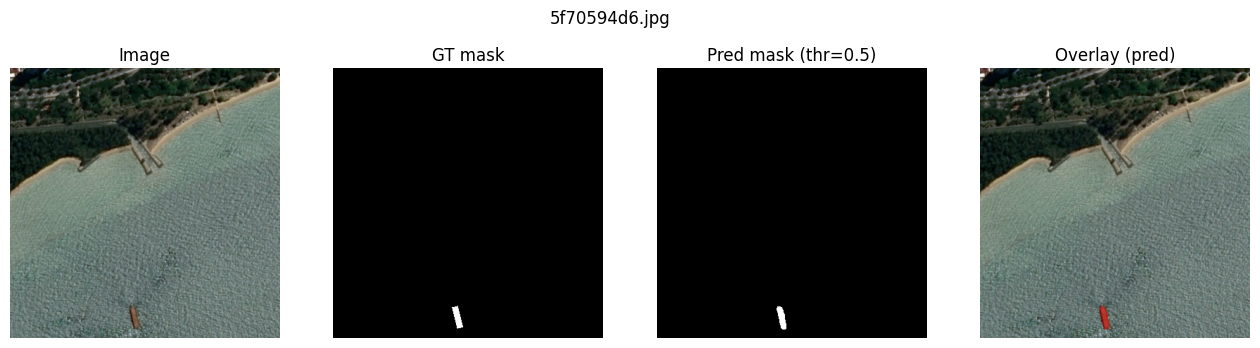

./airbus_data/train_v2\821be7828.jpg


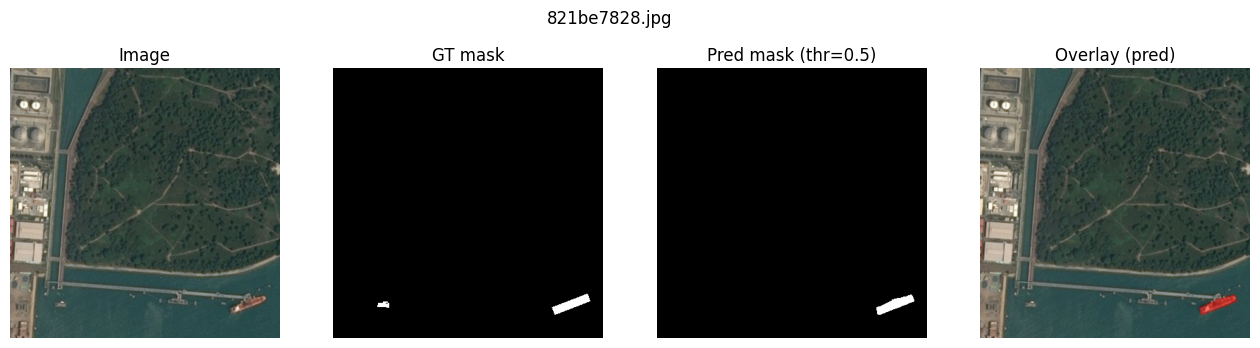

./airbus_data/train_v2\bac64d716.jpg


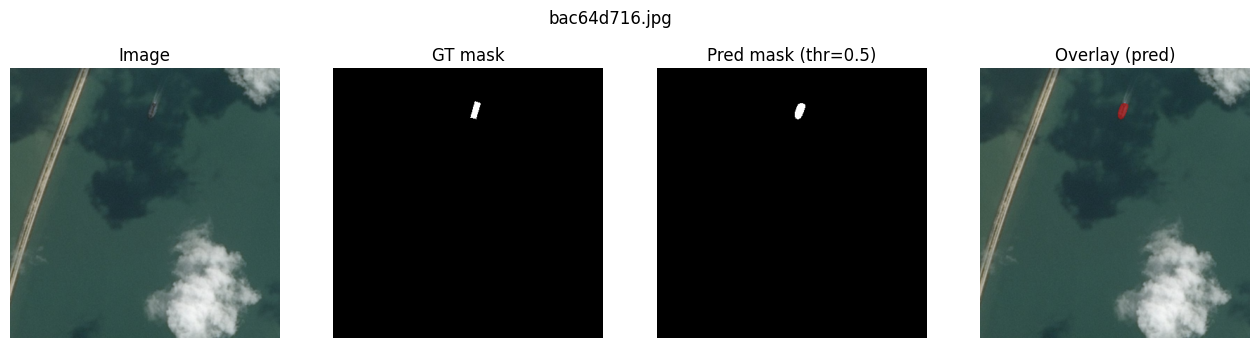

./airbus_data/train_v2\c4ab39e1e.jpg


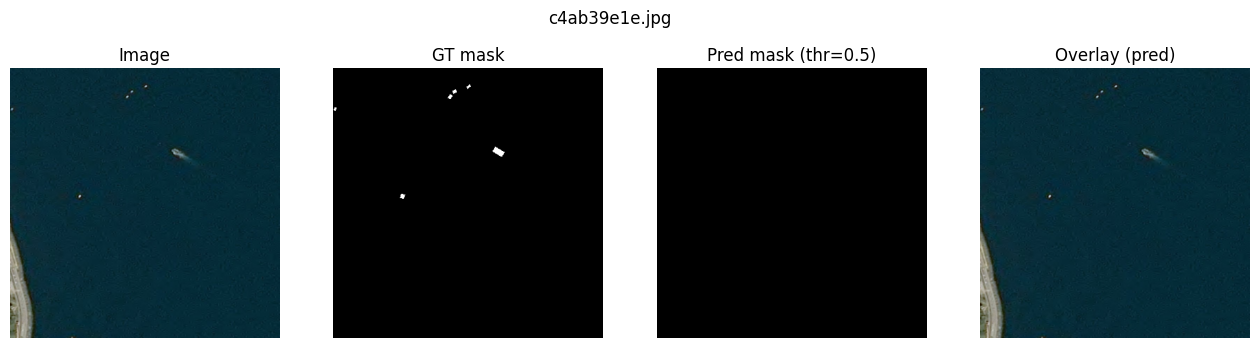

./airbus_data/train_v2\8fabe561f.jpg


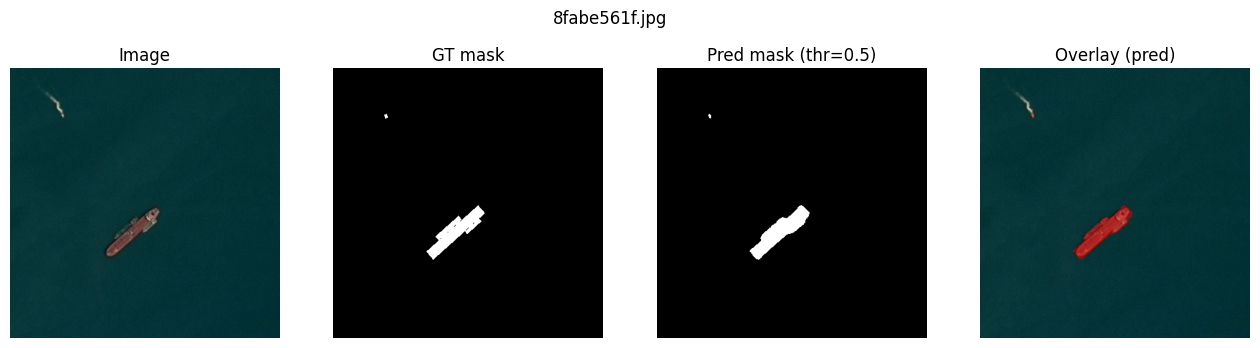

./airbus_data/train_v2\21c89d41e.jpg


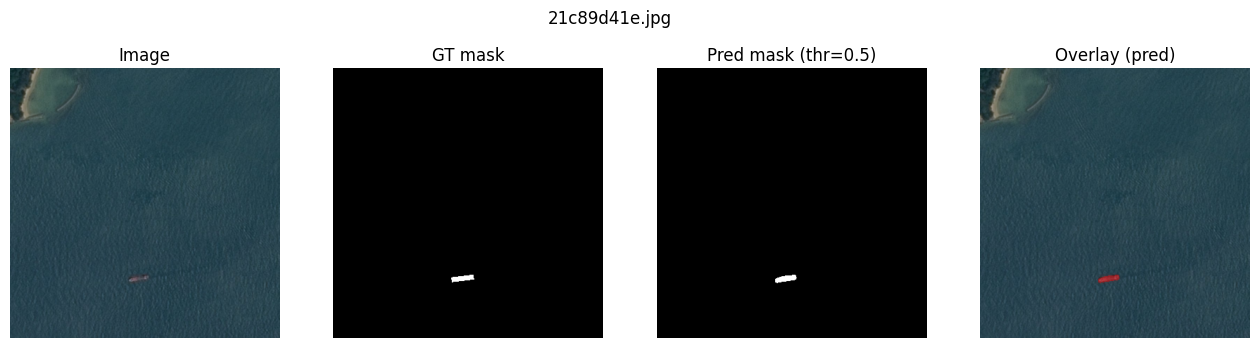

./airbus_data/train_v2\68cccb0a9.jpg


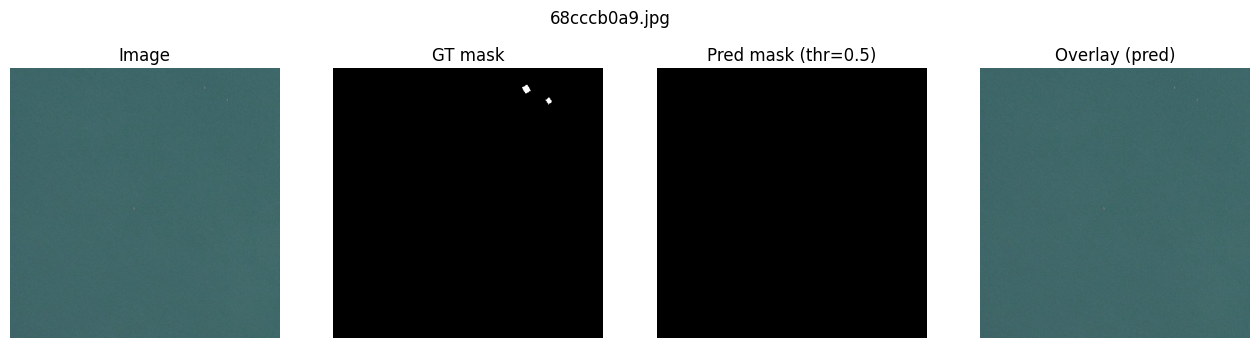

./airbus_data/train_v2\7ea8d8d96.jpg


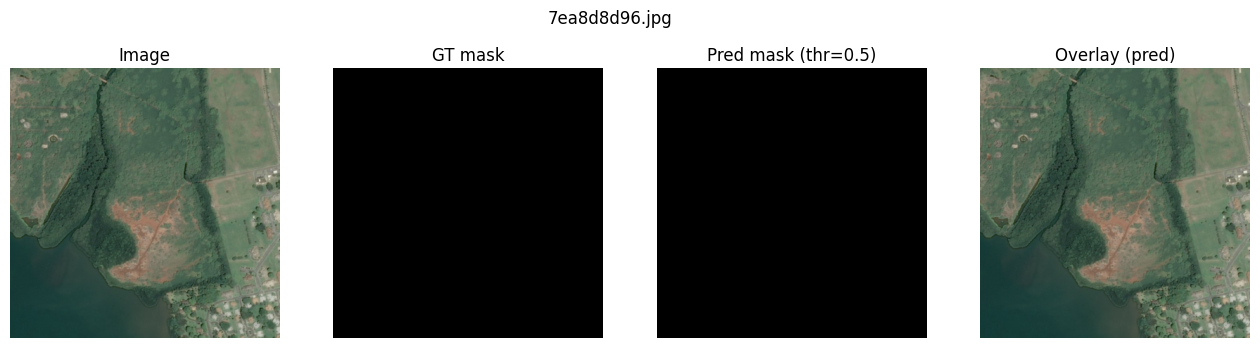

./airbus_data/train_v2\fb513b540.jpg


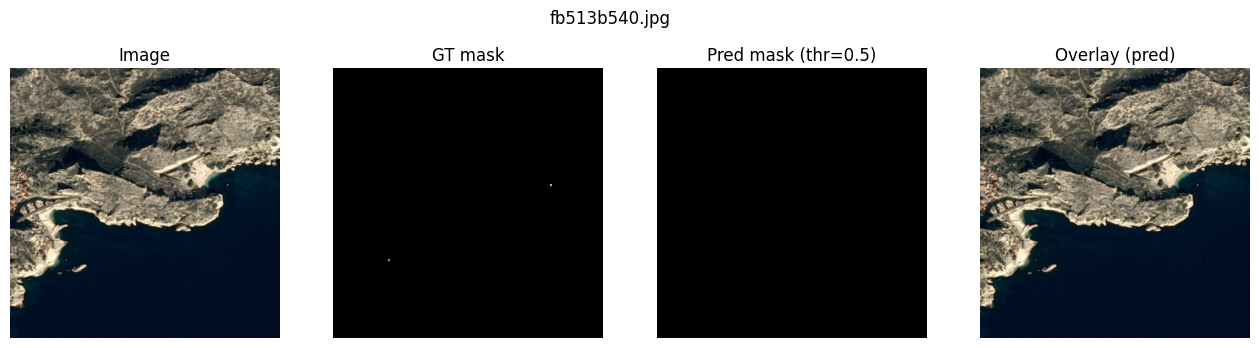

In [24]:
# =========================================
# Inference + visualization: Image | GT mask | Pred mask | Overlay
# (Uses TRAIN images because test set has no labels)
# =========================================
THRESHOLD = 0.5
IMG_SIZE = (384, 384)        # (W,H) for PIL
ORIG_SHAPE = (768, 768)      # (H,W) for Airbus masks
def tensor_to_hwc01(x_chw):
    x = x_chw.detach().cpu().numpy()
    x = np.transpose(x, (1, 2, 0))
    return np.clip(x, 0, 1)

def overlay_mask(image_hwc01, mask_hw, alpha=0.5):
    # simple red overlay
    img = image_hwc01.copy()
    m = (mask_hw > 0).astype(np.float32)
    red = np.zeros_like(img)
    red[..., 0] = 1.0
    return img * (1 - alpha * m[..., None]) + red * (alpha * m[..., None])

with torch.no_grad():
    for fname in sample_files:
        img_path = os.path.join(TRAIN_IMG_DIR, fname)

        # model input
        x, pil_img = load_test_image(img_path, size=IMG_SIZE)  # returns tensor + PIL resized image
        print(img_path)
        x = x.to(DEVICE)

        # prediction
        logits = model(x)
        probs = torch.sigmoid(logits)[0, 0]
        pred_mask = (probs > THRESHOLD).float().cpu().numpy().astype(np.uint8)

        # ground truth mask from CSV (original 768x768), then resize to match model input
        gt_mask_full = build_gt_mask(fname, train_df, shape=ORIG_SHAPE)   # [768,768]
        gt_mask = resize_mask_nearest(gt_mask_full, size=IMG_SIZE)        # [384,384]

        # visuals
        img_np = np.asarray(pil_img).astype(np.float32) / 255.0
        overlay_pred = overlay_mask(img_np, pred_mask, alpha=0.45)

        plt.figure(figsize=(16, 4))
        plt.suptitle(fname)

        plt.subplot(1, 4, 1)
        plt.title("Image")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title("GT mask")
        plt.imshow(gt_mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title(f"Pred mask (thr={THRESHOLD})")
        plt.imshow(pred_mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title("Overlay (pred)")
        plt.imshow(np.clip(overlay_pred, 0, 1))
        plt.axis("off")

        plt.show()


Demo test images: ['8fef6641a.jpg', 'd800518e0.jpg', '4d541ccc1.jpg', 'a24799fbb.jpg', '077a05bfe.jpg', 'a50393425.jpg', 'ad17b437a.jpg', 'dddd92c59.jpg', '3823d3e86.jpg', '44c077130.jpg', '0c951d93a.jpg', '6a27f2522.jpg', '647d00370.jpg', 'aa34ea8d6.jpg', '240285593.jpg', '1569d970b.jpg', '7bb34cf04.jpg', '01ece81e5.jpg', '8bb60a003.jpg', 'fa9265467.jpg', '40aca88ed.jpg', '0677ef219.jpg', '1316b2b66.jpg', '2ac333ebe.jpg', 'f3f88266e.jpg', 'e22cfa01c.jpg', 'da5bc16b9.jpg', '9f627f1bd.jpg', '8dd54731d.jpg', 'f66a81410.jpg', '6b4d18ba2.jpg', 'df850e588.jpg', 'ad6f0e8f8.jpg', '5ccd5e82b.jpg', '8efbf81c0.jpg', 'ed48357f4.jpg', '11a6f385d.jpg', '6b373490f.jpg', '05b4322ac.jpg', '4272a0d22.jpg', 'd7150f8e3.jpg', '966217208.jpg', 'b290a537a.jpg', '4b32f4565.jpg', 'cb8df9e68.jpg', '72d0fabe6.jpg', '9709088b8.jpg', '19705bd17.jpg', 'b32dacd5a.jpg', '4ae18ab5a.jpg', 'a97fb2791.jpg', '961f08662.jpg', 'f06c58505.jpg', '1dd8bd04b.jpg', 'a2bf8d273.jpg', '845d212b3.jpg', 'fb0cd357f.jpg', '52c4936d1.j

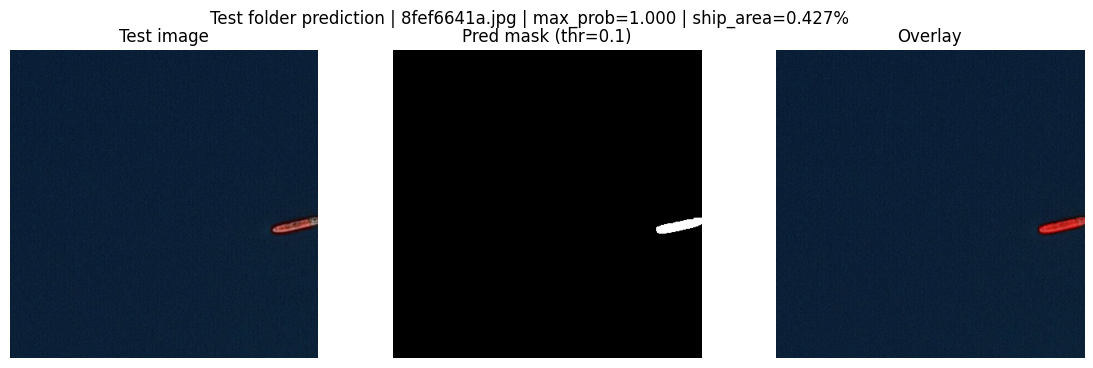

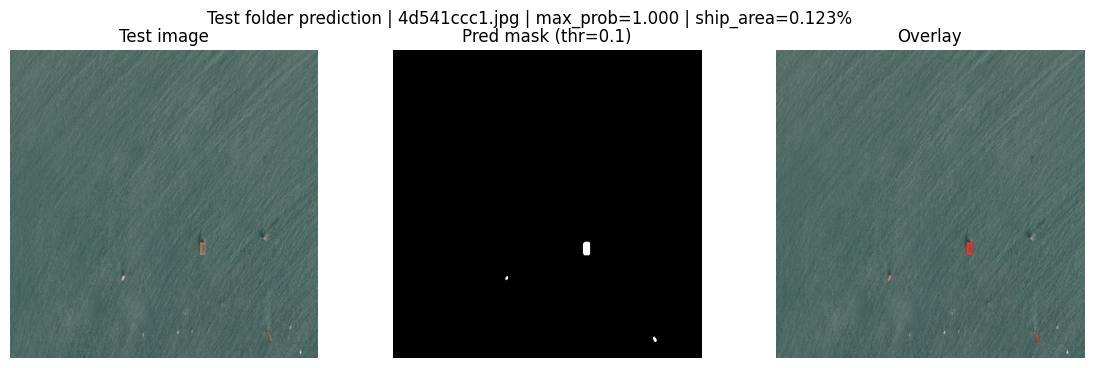

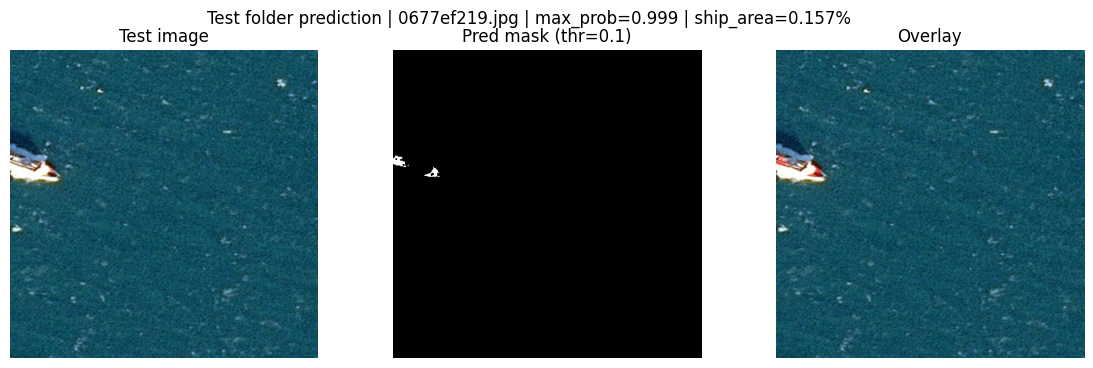

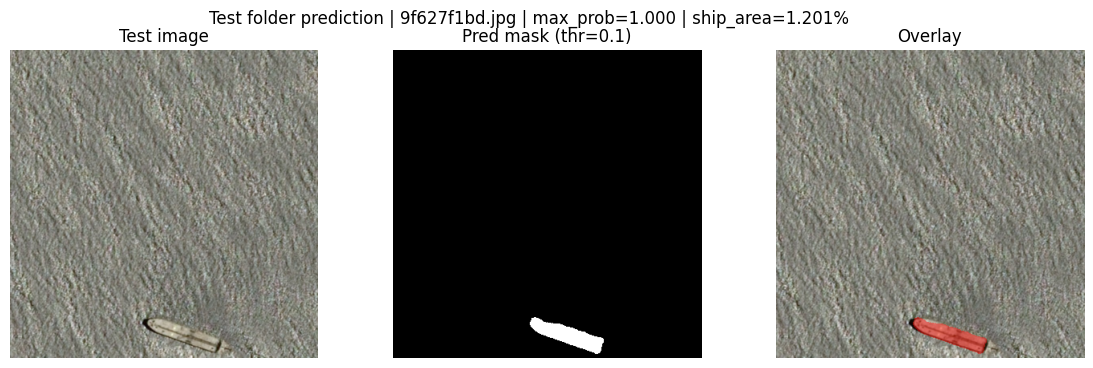

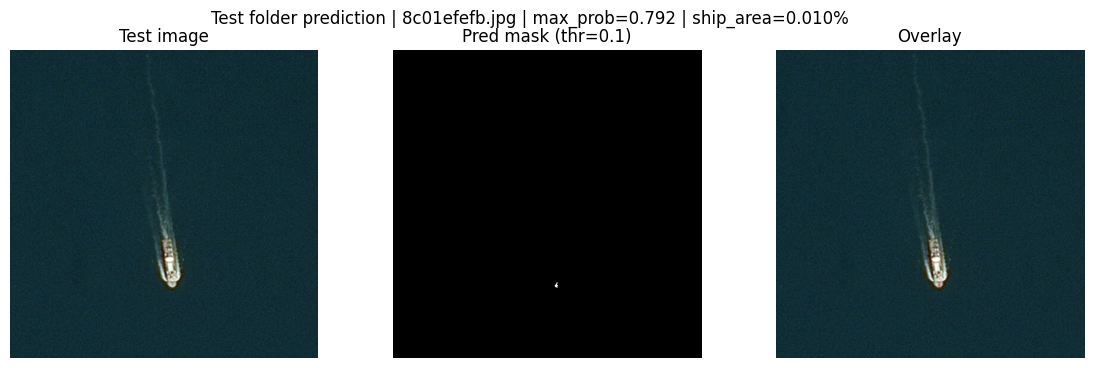

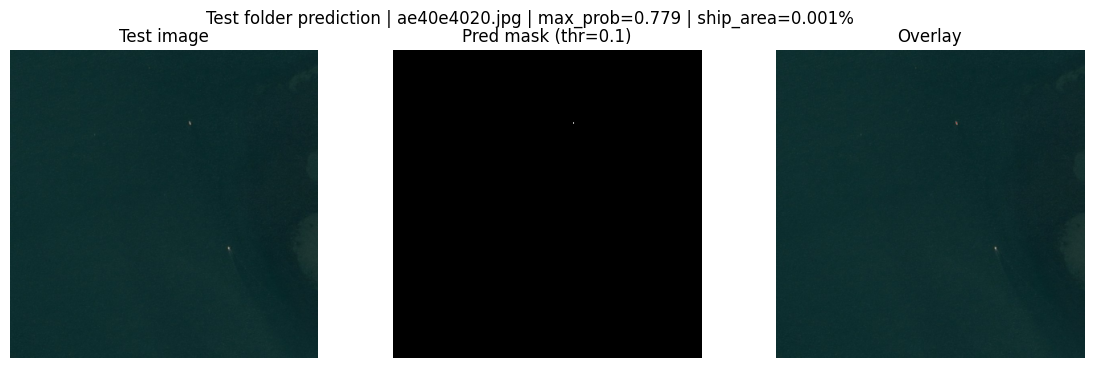

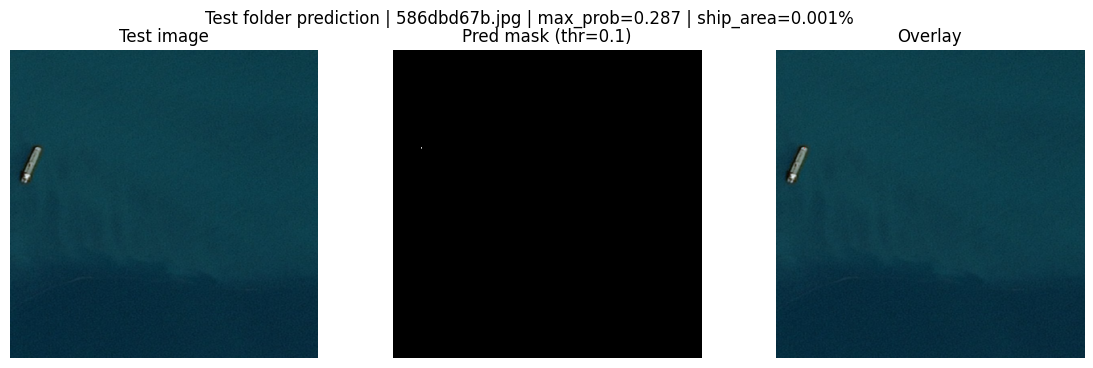

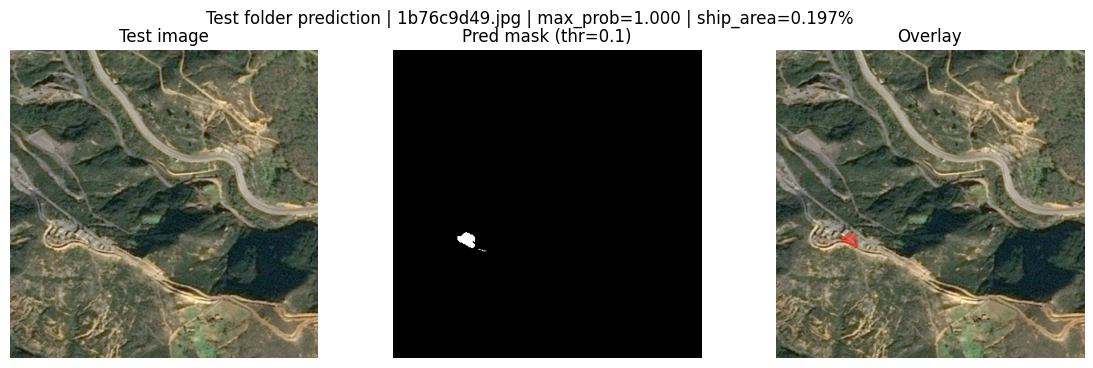

In [40]:
### import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- pick demo images from test_v2 ---
N_SHOW = 100
test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith((".jpg",".jpeg",".png"))]
test_files.sort()

random.seed(30)
demo_files = random.sample(test_files, k=min(N_SHOW, len(test_files)))
print("Demo test images:", demo_files)

# --- image loader (must match training preprocessing) ---
IMG_SIZE = (384, 384)  # (W,H) - set to your training size

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

def preprocess_pil(pil_img, size_wh=IMG_SIZE):
    pil_img = pil_img.convert("RGB").resize(size_wh, resample=Image.BILINEAR)
    img = np.asarray(pil_img).astype(np.float32) / 255.0  # HWC [0,1]
    # normalize
    img = (img - np.array(MEAN, dtype=np.float32)) / np.array(STD, dtype=np.float32)
    # HWC -> CHW
    img = np.transpose(img, (2,0,1))
    x = torch.from_numpy(img).unsqueeze(0)  # [1,3,H,W]
    return x, pil_img

def denorm_for_plot(pil_img):
    return np.asarray(pil_img).astype(np.float32) / 255.0

def overlay_mask(image_hwc01, mask_hw, alpha=0.45):
    img = image_hwc01.copy()
    m = (mask_hw > 0).astype(np.float32)
    red = np.zeros_like(img)
    red[..., 0] = 1.0
    return img * (1 - alpha * m[..., None]) + red * (alpha * m[..., None])

# --- run predictions ---
model.eval()
THRESHOLD = 0.1

with torch.no_grad():
    for fname in demo_files:
        path = os.path.join(TEST_IMG_DIR, fname)
        pil = Image.open(path)

        x, pil_resized = preprocess_pil(pil)
        x = x.to(DEVICE).float()

        logits = model(x)                    # [1,1,H,W]
        probs = torch.sigmoid(logits)[0,0]   # [H,W]
        pred = (probs > THRESHOLD).float().cpu().numpy().astype(np.uint8)

        # simple "ship detected" score:
        max_prob = float(probs.max().item())
        area_frac = float(pred.mean())  # fraction of pixels predicted as ship

        img_np = denorm_for_plot(pil_resized)
        ov = overlay_mask(img_np, pred, alpha=0.45)
        if max_prob >=0.1:

            
            plt.figure(figsize=(14,4))
            plt.suptitle(f"Test folder prediction | {fname} | max_prob={max_prob:.3f} | ship_area={area_frac*100:.3f}%")
    
            plt.subplot(1,3,1)
            plt.title("Test image")
            plt.imshow(img_np)
            plt.axis("off")
    
            plt.subplot(1,3,2)
            plt.title(f"Pred mask (thr={THRESHOLD})")
            plt.imshow(pred, cmap="gray")
            plt.axis("off")
    
            plt.subplot(1,3,3)
            plt.title("Overlay")
            plt.imshow(np.clip(ov, 0, 1))
            plt.axis("off")
    
            plt.show()


In [46]:
# masks == train_df (CSV)
gt_has_ship_map = (
    masks["EncodedPixels"]
    .notna()
    .groupby(masks["ImageId"])
    .any()
    .to_dict()
)

def gt_has_ship(image_id):
    return bool(gt_has_ship_map.get(image_id, False))


def evaluate_image_level_detection(
    loader,
    model,
    device="cuda",
    prob_threshold=0.4   # image-level threshold
):
    model.eval()

    TP = FP = TN = FN = 0

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(tqdm(loader)):
            x = x.to(device).float()

            logits = model(x)
            probs = torch.sigmoid(logits)   # [B,1,H,W]

            # image-level confidence (most robust)
            img_conf = probs.amax(dim=(1,2,3))  # [B]

            B = x.shape[0]
            for i in range(B):
                # image id from dataset (safe indexing)
                img_id = loader.dataset.image_ids[batch_idx * loader.batch_size + i]

                gt = gt_has_ship(img_id)
                pred = img_conf[i].item() > prob_threshold

                if pred and gt:
                    TP += 1
                elif pred and not gt:
                    FP += 1
                elif (not pred) and gt:
                    FN += 1
                else:
                    TN += 1

    # metrics
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    print("\n--- Image-level detection results ---")
    print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"Accuracy={accuracy:.4f}")

    model.train()
    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    }
results = evaluate_image_level_detection(
    loader=demo_loader,
    model=model,
    device=DEVICE,
    prob_threshold=0.4   # tune this if needed
)
for t in [0.2, 0.3, 0.4, 0.5]:
    print(f"\nThreshold = {t}")
    evaluate_image_level_detection(demo_loader, model, DEVICE, prob_threshold=t)



100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.45it/s]



--- Image-level detection results ---
TP=801 | FP=12 | FN=1327 | TN=4243
Precision=0.9852
Recall=0.3764
Accuracy=0.7902

Threshold = 0.2


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.45it/s]



--- Image-level detection results ---
TP=831 | FP=14 | FN=1297 | TN=4241
Precision=0.9834
Recall=0.3905
Accuracy=0.7946

Threshold = 0.3


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.44it/s]



--- Image-level detection results ---
TP=816 | FP=12 | FN=1312 | TN=4243
Precision=0.9855
Recall=0.3835
Accuracy=0.7926

Threshold = 0.4


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.45it/s]



--- Image-level detection results ---
TP=801 | FP=12 | FN=1327 | TN=4243
Precision=0.9852
Recall=0.3764
Accuracy=0.7902

Threshold = 0.5


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.45it/s]


--- Image-level detection results ---
TP=793 | FP=10 | FN=1335 | TN=4245
Precision=0.9875
Recall=0.3727
Accuracy=0.7893
